## This objective of this notebook is to map GLOBAL return periods
- Other notebooks will make Regional, Conflict Zones, Country, Admin, and Cell-year based return periods

#### First we need to set the working directory so relevant functions can be located

In [2]:
import os
import sys

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("The current Working Directory is:", current_directory)

# Get the path to the base directory (VIEWS_FAO_index)
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(f'The base directory will be set to: {base_dir}')

# Add the base directory to sys.path
sys.path.insert(0, base_dir)

The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index


#### Next we load the functions

In [3]:
# delte this is temporary--
from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import calculate_histogram_data


from src.utils.universal_functions.setup.generate_base_file import give_primary_frame
from src.utils.universal_functions.setup.generate_percentiles import get_percentiles
from src.utils.universal_functions.setup.define_scale import select_scale

from src.utils.functions_for_return_periods.insurance_products_for_RP import insurance_files

from src.utils.universal_functions.setup.build_directory import float_to_custom_string, ensure_directory_exists


#Functions for graphics:
from src.utils.functions_for_graphics.construct_custom_symbology import user_defined_colormap, display_percentile_color_table, assign_color_to_zero_values, process_and_merge_return_periods


from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import clean_info_dataframe, query_and_sort_annual_table, provide_values_at_input_return_periods, retrieve_geodataframe, define_year_to_map, query_geodataframe

from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_table import image_save_returnperiodtable
from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_lineplot import plot_histogram_with_lineplot_4
from src.utils.functions_for_graphics.individual_graphics.image_annual_summary_table import plot_and_colorize_annual_table
from src.utils.functions_for_graphics.individual_graphics.image_map_for_Ei import image_save_map_E_i

#Mapping structure:
from src.utils.functions_for_graphics.layout_formats.event_cat_rp import map_event_cat_rp
from src.utils.functions_for_graphics.layout_formats.summary_of_top_years import map_top_years
#from src.utils.functions_for_graphics.layout_formats.Layout_single_method_option1 import mapped_option1


#functions for all methods
from src.utils.universal_functions.FAO_table_formatting.generate_output_tables import generate_and_give_info_dataframe, append_return_periods_to_annual_table

The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The curren

### Provide user inputs to caputure a dataframe for `Conflict History`

In [20]:
user_start_year = int(input("Enter a start year between 1989 and 2024: ").strip())
start_year = user_start_year - 1

user_end_year = int(input("Enter a end year between 1989 and 2024: ").strip())
end_year = user_end_year + 1

data = give_primary_frame('Fatalities_fao_pgm', 'cm_properties', start_year, end_year)

100%|██████████| 40.0M/40.0M [00:03<00:00, 11.5MB/s]


Queryset Fatalities_fao_pgm read successfully 
Queryset cm_properties read successfully 
['month_id', 'pg_id', 'C_start_year', 'C_end_year', 'pop_gpw_sum', 'country_name', 'ged_sb', 'ged_ns', 'ged_os', 'year', 'fatalities_sum', 'country_id']


Does this exist in pipeline:

Notes:

In [21]:
#display(data)
data_working_copy = data.copy()
unique_countries = data_working_copy['country_name'].unique()
print(unique_countries)

['South Africa' 'Lesotho' 'Swaziland' 'Botswana' 'Mozambique' 'Madagascar'
 'Zimbabwe' 'Mauritius' 'Angola' 'Zambia' 'Malawi' 'Congo, DRC' 'Comoros'
 'Tanzania' 'Seychelles' 'Congo' 'Burundi' 'Kenya' 'Gabon' 'Rwanda'
 'Somalia' 'Uganda' 'Sao Tome and Principe' 'Equatorial Guinea' 'Cameroon'
 'Central African Republic' 'Sudan' 'Ethiopia' 'Liberia' "Cote d'Ivoire"
 'Nigeria' 'Ghana' 'Togo' 'Benin' 'Sierra Leone' 'Guinea' 'Chad'
 'Burkina Faso' 'Mali' 'Guinea-Bissau' 'Djibouti' 'Senegal' 'Niger'
 "Yemen People's Republic" 'The Gambia' 'Yemen Arab Republic' 'Cape Verde'
 'Mauritania' 'Saudi Arabia' 'Oman' 'Libya' 'Algeria' 'Morocco' 'Egypt'
 'United Arab Emirates' 'Qatar' 'Iran' 'Pakistan' 'Bahrain' 'Kuwait'
 'Jordan' 'Iraq' 'Afghanistan' 'Israel' 'Tunisia' 'Syria' 'Lebanon'
 'Turkey' 'USSR' 'Greece' 'Bulgaria' 'Namibia' 'Yemen' 'Georgia'
 'Turkmenistan' 'Azerbaijan' 'Armenia' 'Eritrea' 'South Sudan']


#### Then we determine percentiles from the `global` data.

- Because the scale is global, there will be a single aggregated summary 

In [22]:
import numpy as np
import pandas as pd

# Compute percentiles 1 to 100
percentile_values = {p: np.percentile(data['fatalities_sum'], p) for p in range(1, 101)}
print(percentile_values)
# Convert to DataFrame
percentile_df = pd.DataFrame(list(percentile_values.items()), columns=['Percentile', 'Value'])

display(percentile_df)

{1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 0.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0, 71: 0.0, 72: 0.0, 73: 0.0, 74: 0.0, 75: 0.0, 76: 0.0, 77: 0.0, 78: 0.0, 79: 0.0, 80: 0.0, 81: 0.0, 82: 0.0, 83: 0.0, 84: 0.0, 85: 0.0, 86: 0.0, 87: 0.0, 88: 0.0, 89: 0.0, 90: 0.0, 91: 0.0, 92: 0.0, 93: 0.0, 94: 0.0, 95: 0.0, 96: 0.0, 97: 0.0, 98: 0.0, 99: 0.0, 100: 178460.0}


,Percentile,Value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0
5,6,0.0
6,7,0.0
7,8,0.0
8,9,0.0
9,10,0.0


#### 99th Percentile = 0

This analysis shows that a fatality value of 1 appears between the 99th and 100th percentile, demonstrating that any occasion of violence, across the global PGM level, is considered to be within the 1 in 100 year return period. 

In [23]:
country = select_scale(unique_countries)

print(f'Country selection is: {country}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
user_value_field = input("Select a field ('Raw fatalities' or 'Per capita fatalities'): ").strip()
if user_value_field == 'Raw fatalities':
    value_field = 'fatalities_sum'

if user_value_field == 'Per capita fatalities':
    value_field = 'percapita_100k'

#value_field = 'fatalities_sum' # or fatalities_sum or percapita_100k

print(f'Value field selection is: {value_field}')
print()

method = input("Select a unit of analysis or special data treatment: ('standard', 'aggregation', or 'smoothing'): ").strip()

#method = 'standard' # 'standard' or 'aggregation' or 'smoothing'
print(f'Method selection is: {method}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'smoothing':
    value_field = 'perca_Mean'

print(value_field)
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
return_period = input("Select a return period calculation: ('Country year', or 'Event year'): ").strip()

#return_period = 'Country year' # 'Event year' or 'Country year'
print(f'Return period calculation: {return_period}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if return_period == 'Event year':
    insurance_attribute = 'return period' # This should eventually be changed and cleaned up
if return_period == 'Country year':
    insurance_attribute = 'Return Period' # This should eventually be changed and cleaned up
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'aggregation':
    aggregation = value = str(int(input("Enter an aggregation unit from 2 to 10: ").strip()))


#aggregation = '3'
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'aggregation' and int(aggregation) <= 1:
    raise ValueError("Aggregation value must be greater than 1 for the 'aggregation' method.")

if method == 'standard' or method == 'smoothing':
    aggregation = '1'
print(f'Aggregation Unit: {aggregation}')
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

option = input("Choose an option to calculate percentiles ('Default', 'User defined', 'All values'): ")
percentiles = get_percentiles(option)
print(percentiles)



Available countries:
South Africa
Lesotho
Swaziland
Botswana
Mozambique
Madagascar
Zimbabwe
Mauritius
Angola
Zambia
Malawi
Congo, DRC
Comoros
Tanzania
Seychelles
Congo
Burundi
Kenya
Gabon
Rwanda
Somalia
Uganda
Sao Tome and Principe
Equatorial Guinea
Cameroon
Central African Republic
Sudan
Ethiopia
Liberia
Cote d'Ivoire
Nigeria
Ghana
Togo
Benin
Sierra Leone
Guinea
Chad
Burkina Faso
Mali
Guinea-Bissau
Djibouti
Senegal
Niger
Yemen People's Republic
The Gambia
Yemen Arab Republic
Cape Verde
Mauritania
Saudi Arabia
Oman
Libya
Algeria
Morocco
Egypt
United Arab Emirates
Qatar
Iran
Pakistan
Bahrain
Kuwait
Jordan
Iraq
Afghanistan
Israel
Tunisia
Syria
Lebanon
Turkey
USSR
Greece
Bulgaria
Namibia
Yemen
Georgia
Turkmenistan
Azerbaijan
Armenia
Eritrea
South Sudan

Options:
1. Enter 'Global' to analyze all data as one entity.
2. Enter one or more country names separated by commas.
3. Enter 'Process all countries' to analyze each country individually.
Country selection is: ['Global']

Value field sele

In [24]:
# def insurance_files(data, country_name, method, return_period_process, percentiles=['90','95','98','99','100'], aggregation_unit='0', eval_field='percapita_100k'):

#conflict_profile, x, y, z = insurance_files(data_working_copy, country, method, return_period, percentiles, aggregation_unit=aggregation, eval_field=value_field)
country_dictionary = insurance_files(data_working_copy, country, method, return_period, percentiles, aggregation_unit=aggregation, eval_field=value_field)


# print(x.head(10))
# print('y dataframe')
# print(y)
# print('z dataframe:')
# print(z)

# max_year = max(x['year'])
# min_year = min(x['year'])

# print(max_year)
# print(min_year)

Index where fatalities_sum equals 1 (fatalities) or 0.1 (per capita): 96.5: 1.0


In [25]:
import pandas as pd 

pd.set_option("display.max_rows", 50)

country_dictionary

{'Global': {'conflict profile': {'ged_sb': 1179054.0,
   'ged_ns': 179982.0,
   'ged_os': 1047416.0,
   'fatalities_sum': 2406452.0},
  'PGY dataframe':          pg_id  year  fatalities_sum  pop_gpw_sum  percapita_100k
  0        62356  1989             0.0      0.00000             NaN
  1        62356  1990             0.0      0.00000             NaN
  2        62356  1991             0.0      0.00000             NaN
  3        62356  1992             0.0      0.00000             NaN
  4        62356  1993             0.0      0.00000             NaN
  ...        ...   ...             ...          ...             ...
  471955  190511  2020             0.0   1989.38623             0.0
  471956  190511  2021             0.0   1989.38623             0.0
  471957  190511  2022             0.0   1989.38623             0.0
  471958  190511  2023             0.0   1989.38623             0.0
  471959  190511  2024             0.0   1989.38623             0.0
  
  [471960 rows x 5 columns],
 

## Lets first investigate the `return period table` and use `Ethiopia` as our example country (assuming Ethiopia was selected among countries above:)

In [26]:
import pandas as pd
df_return_period = country_dictionary['Global']['return period table']
pd.set_option('display.max_rows', None)

display(df_return_period)

,Percentile,fatalities_sum,Occurrence,Return Period,Payout Rate
0,1,0.0,0,1.0,undefined
1,2,0.0,0,1.0,undefined
2,3,0.0,0,1.0,undefined
3,4,0.0,0,1.0,undefined
4,5,0.0,0,1.0,undefined
5,6,0.0,0,1.0,undefined
6,7,0.0,0,1.0,undefined
7,8,0.0,0,1.0,undefined
8,9,0.0,0,1.0,undefined
9,10,0.0,0,1.1,undefined


## We are now progressing the `annual summary report` table 

#### This table provides us with a conflict history and several ways of sorting violence over time which will be used in the graphic development

***Tech Debt:*** *Add total fatalities to this table*

*If you were to run the previous tool with standard (1x1) treatment applied, why is the value of 1.0 fatality appear at 96.6 rather than 99.x in the code above?*

This is because the preceding cell is taking PGY values rather than PGM data.

In [28]:
for c in country:
    print(c)
    df_annual_report = country_dictionary[c]['annual summary report']
    display(df_annual_report)



#produces graphics, tables, and maps for the CELL TYPE RETURN PERIOD:
y_rows = df_annual_report.shape[0]

#-----Define how to sort the map to inform graphics---------------------------------------------------------------
#-------------------START-----------------------------------------------------------------------------------------

sorted_annual_table = query_and_sort_annual_table(df_annual_report, field_to_sort='average_value', number_of_rows=y_rows)
sorted_annual_table.iloc[:, 1:] = sorted_annual_table.iloc[:, 1:].round(1)
sorted_annual_table = sorted_annual_table.reset_index(drop=True)

print(sorted_annual_table)
#--------------------END-------------------------------------------------------------------------------------------
#-----TDefine how to sort the map to inform graphics---------------------------------------------------------------


Global


,year,first_value,second_value,third_value,average_value,total_fatalities
0,1989,9083.0,3050.0,2700.0,4.375669,35603.0
1,1990,18700.0,9983.0,4283.0,8.532450,69425.0
2,1991,7400.0,2400.0,2360.0,4.435091,37049.0
3,1992,2000.0,1214.0,1002.0,2.070794,17748.0
4,1993,6277.0,4202.0,2513.0,4.305249,37833.0
5,1994,229104.0,128574.0,123467.0,86.064502,774982.0
6,1995,4080.0,1504.0,1000.0,2.378524,21934.0
7,1996,8538.0,7632.0,5529.0,6.306742,59620.0
8,1997,4693.0,2363.0,2200.0,4.085569,39569.0
9,1998,3288.0,1401.0,1377.0,3.290693,32633.0


    year  first_value  second_value  third_value  average_value  \
0   1994     229104.0      128574.0     123467.0           86.1   
1   2022     157317.0        1428.0       1263.0           14.9   
2   2021     116450.0        4361.0       2068.0           12.5   
3   1990      18700.0        9983.0       4283.0            8.5   
4   2014      10159.0        7031.0       2998.0            7.4   
5   1999      30019.0       15143.0       2852.0            7.2   
6   2000      49207.0         753.0        719.0            6.3   
7   1996       8538.0        7632.0       5529.0            6.3   
8   2015       5941.0        5603.0       2748.0            6.0   
9   2016       8797.0        3998.0       3164.0            5.3   
10  2017       6685.0        5692.0       3617.0            5.1   
11  2013       9912.0        7734.0       5095.0            5.0   
12  1991       7400.0        2400.0       2360.0            4.4   
13  1989       9083.0        3050.0       2700.0            4.

## Now lets print the primary dataframe containing our data we will query, based on the annual report

In [29]:
for c in country:
    print(c)
    df_pgy_dataframe = country_dictionary[c]['PGY dataframe']
    display(df_pgy_dataframe.head())

Global


,pg_id,year,fatalities_sum,pop_gpw_sum,percapita_100k
0,62356,1989,0.0,0.0,NaN
1,62356,1990,0.0,0.0,NaN
2,62356,1991,0.0,0.0,NaN
3,62356,1992,0.0,0.0,NaN
4,62356,1993,0.0,0.0,NaN


### Now we progress toward the mapping workflow

*This was the prior workflow*

In [30]:
info_df, color_scheme = generate_and_give_info_dataframe(df_return_period, return_period, value_field, insurance_attribute)

info_df

Updated row 0 with values from row 1: 0.0, 0


,Return Period,Range,Color,Label
0,0,0 - 0.0,#d5dbdb,Below 1 in 10 year
1,10,0.0 - 0.0,#377eb8,1 in 10 year
2,20,0.0 - 8.0,#e6ab02,1 in 20 year
3,50,8.0 - 33.0,#762a83,1 in 50 year
4,100,33.0 - 100000,#b2182b,1 in 100 year


#### Here we will create a custom mapper function to assign unique hex color codes to each return period mapped from the previous step

- the following code works perfectly


Available Colors:
black, white, gray, silver, lightgray, darkgray, red, darkred, lightcoral, indianred, salmon, darksalmon, tomato, orangered, firebrick, brown, maroon, orange, darkorange, gold, yellow, lightyellow, khaki, olive, darkolivegreen, green, darkgreen, forestgreen, lime, limegreen, lightgreen, palegreen, springgreen, seagreen, mediumseagreen, mediumspringgreen, teal, darkcyan, cyan, lightcyan, aqua, aquamarine, turquoise, mediumturquoise, darkturquoise, steelblue, deepskyblue, dodgerblue, blue, mediumblue, darkblue, navy, royalblue, cornflowerblue, skyblue, lightskyblue, slateblue, mediumslateblue, darkslateblue, purple, mediumorchid, darkorchid, darkviolet, violet, blueviolet, indigo, magenta, darkmagenta, fuchsia, plum, orchid, thistle, pink, lightpink, hotpink, deeppink, mediumvioletred

You entered 10 thresholds. Now, enter 10 colors corresponding to them.

Percentile to Color Mapping:
  1.0: lightgray
  90.0: gray
  95.0: cyan
  97.0: blue
  98.0: purple
  98.5: gold
 

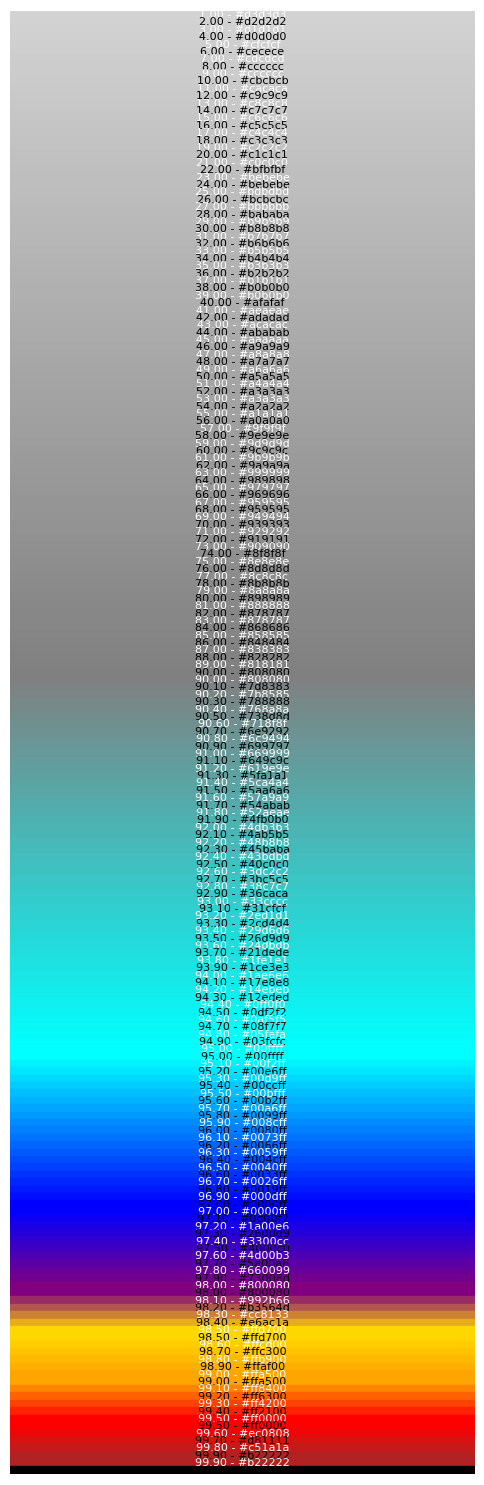

In [31]:
dynamic_colormap_df_corrected = user_defined_colormap()
print(dynamic_colormap_df_corrected)
# Display the color table for percentiles
display_percentile_color_table(dynamic_colormap_df_corrected)

#### Merge the symbology dataframe to the `df_return_period` so that both a percentile and fatality value are associated with a hex_value.

`assign_color_to_zero_values`:

- Retains only rows where fatalities_sum > 0 and the last row that contains zero fatalities.
- Assigns a user-specified color name to the last zero-value row and converts it to HEX.
- Sorts the DataFrame by Percentile in ascending order.
- Removes duplicate rows to ensure unique combinations.
- Returns the modified DataFrame.
    
`process_and_merge_return_periods`:

Processes and merges return period data with a dynamic colormap based on Percentile values.
    
Steps:
1. Replaces 'max' in the Percentile column of df_return_period with 100.
2. Converts Percentile columns to float and rounds to one decimal place.
3. Merges df_return_period with dynamic_colormap_df_corrected on Percentile.
4. Prompts the user to enter a color name for zero values.
5. Assigns the user-defined color to zero values using `assign_color_to_zero_values`.
    
Parameters:
- df_return_period (pd.DataFrame): DataFrame containing return period data with a 'Percentile' column.
- dynamic_colormap_df_corrected (pd.DataFrame): DataFrame containing colormap mappings with a 'Percentile' column.
    
Returns:
- pd.DataFrame: The merged and updated dataframe with the assigned zero-value color.



In [32]:

df_updated = process_and_merge_return_periods(df_return_period, dynamic_colormap_df_corrected)

# pd.set_option("display.max_rows", 100)

# df_return_period["Percentile"] = df_return_period["Percentile"].replace("max", 100)
# df_return_period["Percentile"] = df_return_period["Percentile"].astype(float).round(1)
# dynamic_colormap_df_corrected["Percentile"] = dynamic_colormap_df_corrected["Percentile"].astype(float).round(1)

# # Perform the join based on the shared Percentile column
# df_merged = df_return_period.merge(dynamic_colormap_df_corrected, on="Percentile", how="left")

# # Prompt user to enter a color name for zero values
# zero_value_color_name = input("Enter the color name to assign to zero values (e.g., 'blue', 'red', 'green'): ")

# # Apply the function with user input
# df_updated = assign_color_to_zero_values(df_merged, zero_value_color_name)

# # Display the updated DataFrame
print(df_updated)

    Percentile  fatalities_sum  Occurrence Return Period Payout Rate hex_value
0         96.0             0.0      455164          25.0   undefined   #d3d3d3
1         96.5             1.0        2074          28.5   undefined   #0040ff
2         97.0             2.0        2536          33.3   undefined   #0000ff
4         97.5             4.0        2539          40.0   undefined   #4000c0
5         98.0             8.0        2493          50.0         75%   #800080
7         98.5            16.0        2368          66.6   undefined   #ffd700
9         99.0            33.0        2416         100.0        100%   #ffa500
11        99.5            84.0        2369         200.0   undefined   #ff0000
13       100.0        229104.0           1            --          --   #000000


#### Now lets plot this Return Period data:
We need:
- A geodataframe of PG data
- identify the year of interest from the primary dataframe
- subset the primary data frame to the specific year of interest
- join the df_updated to this 
- map it.

In [ ]:
# Load geodataframe:
import geopandas as gpd

# Provide the path to your shapefile
shapefile_path = "/Users/gbenz/Documents/VIEWS_FAO_index/data/raw_viewser/pg_viewser_extent.shp"

# Load the shapefile as a GeoDataFrame
gdf = gpd.read_file(shapefile_path)

# Display the first few rows
print(gdf.head())

gdf1 = retrieve_geodataframe(aggregation)

print(gdf1.head())

### Generate a new dictionary associating values to colors to incorporate into the mapping function

In [33]:
import pandas as pd

def create_fatalities_range_to_hex_mapping(df):
    """
    Creates a range-based fatalities-to-hex color mapping dictionary,
    including percentile labels for legend display.

    Parameters:
    - df: DataFrame containing 'fatalities_sum', 'hex_value', and 'Percentile' columns.

    Returns:
    - Dictionary with tuple keys representing (lower_bound, upper_bound), 
      and values as a tuple (hex_color, percentile_label).
    """
    # Create a dictionary mapping fatalities_sum to (hex_value, Percentile), prioritizing the first occurrence
    fatalities_to_hex = {}
    for index, row in df.iterrows():
        if row["fatalities_sum"] not in fatalities_to_hex:
            fatalities_to_hex[row["fatalities_sum"]] = (row["hex_value"], row["Percentile"])

    # Convert the fatalities_sum values into a range-based mapping
    fatalities_range_to_hex = {}
    sorted_fatalities = sorted(fatalities_to_hex.keys())

    for i in range(len(sorted_fatalities) - 1):
        lower_bound = sorted_fatalities[i]
        upper_bound = sorted_fatalities[i + 1]
        hex_color, percentile_label = fatalities_to_hex[lower_bound]
        fatalities_range_to_hex[(lower_bound, upper_bound)] = (hex_color, percentile_label)

    # Assign the last value to the highest range
    last_fatality = sorted_fatalities[-1]
    fatalities_range_to_hex[(last_fatality, float("inf"))] = (
        fatalities_to_hex[last_fatality][0],  # Hex color
        fatalities_to_hex[last_fatality][1]   # Percentile
    )

    return fatalities_range_to_hex


# Generate the range-based fatalities-to-hex mapping
fatalities_range_to_hex_mapping = create_fatalities_range_to_hex_mapping(df_updated)

# Display the mapping
print(fatalities_range_to_hex_mapping)


{(0.0, 1.0): ('#d3d3d3', 96.0), (1.0, 2.0): ('#0040ff', 96.5), (2.0, 4.0): ('#0000ff', 97.0), (4.0, 8.0): ('#4000c0', 97.5), (8.0, 16.0): ('#800080', 98.0), (16.0, 33.0): ('#ffd700', 98.5), (33.0, 84.0): ('#ffa500', 99.0), (84.0, 229104.0): ('#ff0000', 99.5), (229104.0, inf): ('#000000', 100.0)}


### Similarly, a new mapping function that references this dictionary:

In [16]:
import os
import geopandas as gpd
import pandas as pd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np
import matplotlib.colors as mcolors

def image_save_map(
    gdf, 
    fatalities_range_to_hex, 
    country, 
    method, 
    returnperiodmethod, 
    year, 
    eval_attribute, 
    aggregation='1', 
    field='percapita_100k', 
    country_label='yes', 
    figure_height=3.5, 
    figure_width=3.5, 
    out_of_sample='no', 
    year_id=1
):
    """
    Save a categorized map image based on a fatalities-to-color mapping dictionary,
    and generate a separate vertical color bar legend.
    """

    def float_to_custom_string(value):
        return f"{value:.2f}"

    def ensure_directory_exists(path):
        if not os.path.exists(path):
            os.makedirs(path)

    figure_height_str = float_to_custom_string(figure_height)
    figure_width_str = float_to_custom_string(figure_width)

    aggregation_string = str(aggregation) + 'x' + str(aggregation)
    base_directory = os.getcwd()

    if aggregation == '1':
        output_path = os.path.join(base_directory, 'files', country, method, returnperiodmethod, 'map_png')
        if out_of_sample == 'yes':
            output_path = os.path.join(base_directory, 'files', country, method, returnperiodmethod, 'out_of_sample', 'map_png')
    else:
        output_path = os.path.join(base_directory, 'files', country, method, returnperiodmethod, aggregation_string, 'map_png')
        if out_of_sample == 'yes':
            output_path = os.path.join(base_directory, 'files', country, method, returnperiodmethod, 'out_of_sample', 'map_png')

    ensure_directory_exists(output_path)

    # Function to get the color and percentile label
    def get_color_label(value):
        for (low, high), (color, percentile) in fatalities_range_to_hex.items():
            if low <= value < high:
                return color, f"≥ {percentile:.1f}%"
        return 'lightgray', 'Undefined'  # Default if not found

    # Assign colors and labels based on fatalities
    gdf['color'], gdf['category_label'] = zip(*gdf[field].apply(get_color_label))

    # Reproject the GeoDataFrame to Web Mercator (EPSG:3857)
    gdf = gdf.to_crs(epsg=3857)

    output_file = os.path.join(output_path, f'{country} conflict year {year_id} in {year} investigating {eval_attribute} with dimensions {figure_width_str}x{figure_height_str}.png')

    # Create the plot with exact figure dimensions
    fig, ax = plt.subplots(figsize=(figure_width, figure_height))
    
    # Plot the data with the assigned colors
    gdf.plot(color=gdf['color'], edgecolor=(0, 0, 0, 0.2), linewidth=0.2, ax=ax)

    # Adjust map zoom to fit bounds
    bounds = gdf.total_bounds
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_aspect('equal', adjustable='datalim')

    # Add a basemap
    #ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

    # Hide the axis
    ax.set_axis_off()

    # Save the figure
    plt.savefig(output_file, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f'Map saved to {output_file}')

    # --- Generate the separate **vertical** color bar legend ---

    legend_output_file = os.path.join(output_path, f'legend_{year_id}.png')

    # Extract color mappings and labels
    percentiles = [v[1] for v in fatalities_range_to_hex.values()]
    colors = [v[0] for v in fatalities_range_to_hex.values()]

    # Create a colormap
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors)
    norm = mcolors.Normalize(vmin=min(percentiles), vmax=max(percentiles))

    # Generate figure for legend
    fig, ax = plt.subplots(figsize=(1, 6))  # Adjust width & height for vertical legend
    fig.subplots_adjust(left=0.5)

    # Create color bar
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax, orientation='vertical')
    cbar.set_label("Percentile Categories")

    # Set percentile labels
    cbar.set_ticks(percentiles)
    cbar.set_ticklabels([f"≥ {p:.1f}%" for p in percentiles])

    # Save the legend separately
    plt.savefig(legend_output_file, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

    print(f'Legend saved to {legend_output_file}')


map for: 0
merged to gdf...


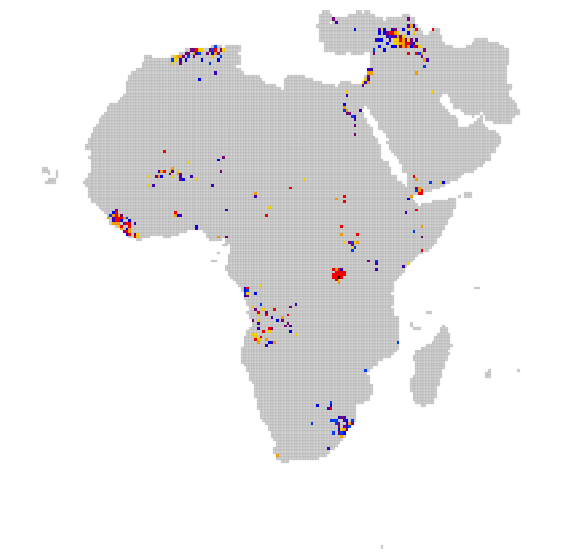

Map saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/Global conflict year 0 in 1994.0 investigating fatalities_sum with dimensions 7.00x7.00.png


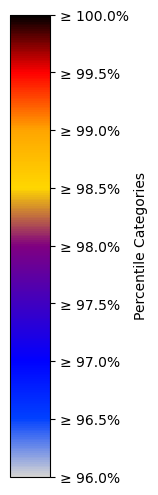

Legend saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/legend_0.png
map for: 1
merged to gdf...


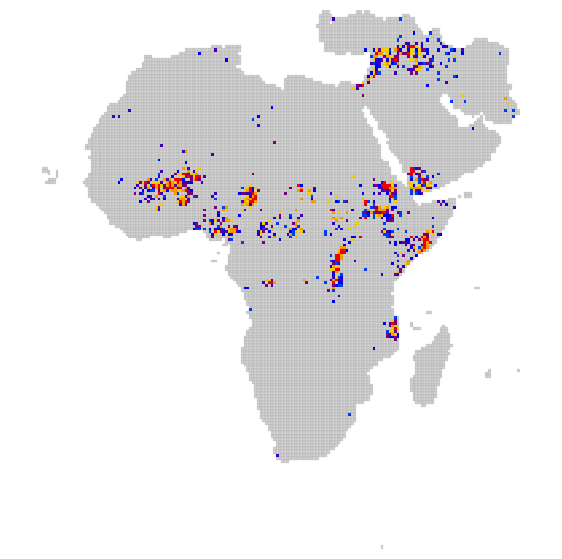

Map saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/Global conflict year 1 in 2022.0 investigating fatalities_sum with dimensions 7.00x7.00.png


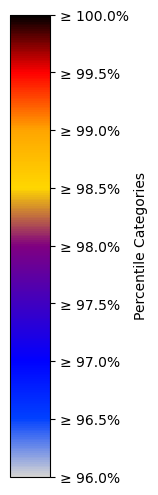

Legend saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/legend_1.png
map for: 2
merged to gdf...


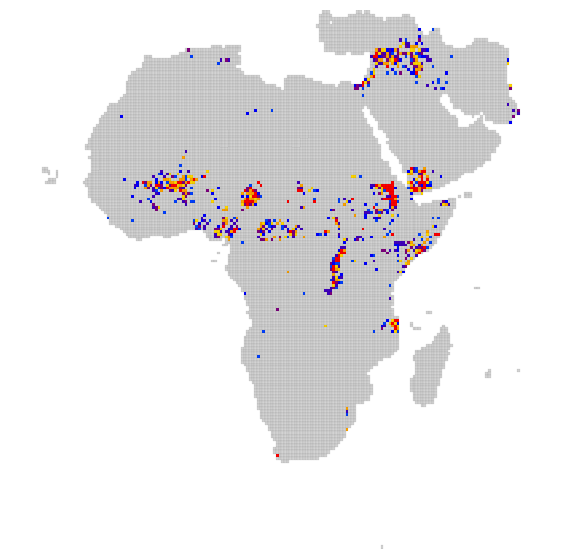

Map saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/Global conflict year 2 in 2021.0 investigating fatalities_sum with dimensions 7.00x7.00.png


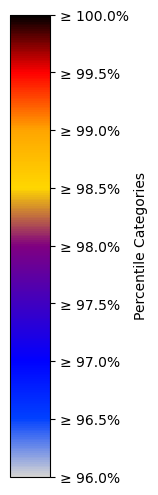

Legend saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/legend_2.png
map for: 3
merged to gdf...


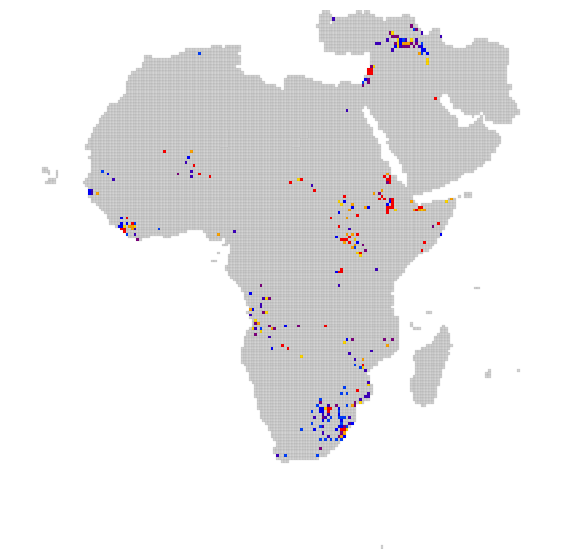

Map saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/Global conflict year 3 in 1990.0 investigating fatalities_sum with dimensions 7.00x7.00.png


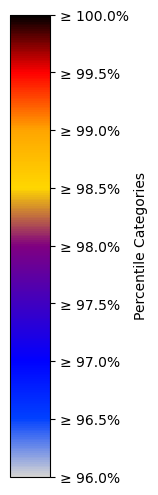

Legend saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/legend_3.png
map for: 4
merged to gdf...


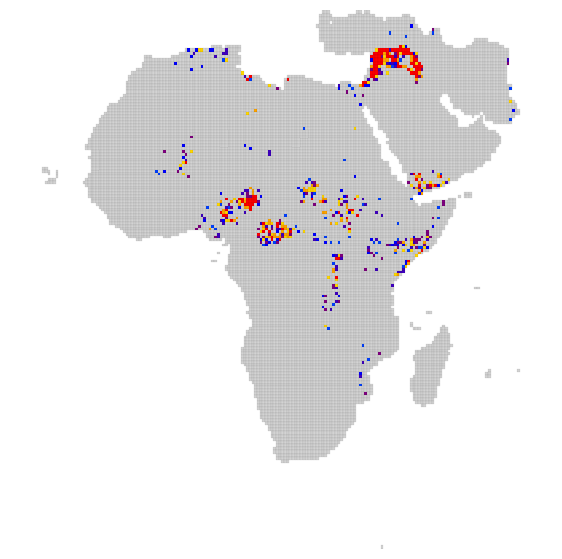

Map saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/Global conflict year 4 in 2014.0 investigating fatalities_sum with dimensions 7.00x7.00.png


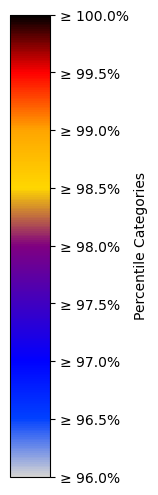

Legend saved to /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods/files/Global/standard/Country year/map_png/legend_4.png


In [34]:

gdf = retrieve_geodataframe(aggregation)

for annual_event in range(min(5, y_rows)):
        print(f'map for: {annual_event}')
        year_to_eval = define_year_to_map(sorted_annual_table, annual_event)
        gdf_merged = query_geodataframe(gdf, df_pgy_dataframe, year_to_eval, field=value_field)
        print('merged to gdf...')

        image_save_map(gdf_merged, 
                        fatalities_range_to_hex_mapping,
                        'Global', 
                        method, 
                        return_period, 
                        year_to_eval, 
                        value_field, 
                        aggregation, 
                        field=value_field, 
                        country_label='no', 
                        figure_height=7, 
                        figure_width=7, 
                        year_id=annual_event)


In [ ]:
# Plot the GeoDataFrame
gdf.plot(figsize=(10, 6), edgecolor='black')

# Show the plot
plt.show()